# War Narratives — Análisis de ciclos retóricos pre-bélicos

**Hipótesis central:**  
> Antes de cada intervención militar de EE.UU. en Medio Oriente, emergen narrativas identificables y recurrentes que siguen una progresión temporal predecible — y este ciclo se ha *acelerado* con el tiempo.

**Casos de estudio:** Golfo 1991 · Afganistán 2001 · Irak 2003 · Libia 2011 · **Irán 2026** ← caso en tiempo real

**Taxonomía de ciclos:**  
① Construcción verificable · ② Redirección · ③ Fabricación de evidencia

**Fuente de datos:** GDELT Project 2.0 (Global Database of Events, Language and Tone)  
**Modo actual:** datos simulados (structuralmente idénticos a GDELT) — ver Sección 1 para activar datos reales

---

## 0. Configuración global

In [1]:
# ── Parámetros del proyecto ────────────────────────────────────────────
USE_REAL_GDELT = True   # Cambiar a False cuando corras en tu entorno local
ROLLING_WINDOW = 7       # días para suavizar series de tiempo

# Ventana de análisis: cuántos días antes de la invasión observar
WINDOW_DAYS = 180

# Paleta por caso (consistente en todas las visualizaciones)
CASE_COLORS = {
    'gulf_1991':       '#378ADD',
    'afghanistan_2001':'#1D9E75',
    'iraq_2003':       '#BA7517',
    'libya_2011':      '#7F77DD',
    'iran_2026':       '#E24B4A',   # rojo — caso activo
}

CASE_LABELS = {
    'gulf_1991':       'Golfo 1991',
    'afghanistan_2001':'Afganistán 2001',
    'iraq_2003':       'Irak 2003',
    'libya_2011':      'Libia 2011',
    'iran_2026':       'Irán 2026 ★',
}

INVASION_DATES = {
    'gulf_1991':        '1991-01-17',
    'afghanistan_2001': '2001-10-07',
    'iraq_2003':        '2003-03-20',
    'libya_2011':       '2011-03-19',
    'iran_2026':        '2026-02-28',
}

print('✓ Configuración cargada')

✓ Configuración cargada


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('✓ Librerías listas')

✓ Librerías listas


---
## 1. Carga de datos

### Opción A — Datos simulados (por defecto, sin conexión)
Usa el archivo `gdelt_mock.parquet` generado localmente.  

### Opción B — GDELT real (activa con `USE_REAL_GDELT = True`)
Descarga datos reales via la GDELT API. Requiere conexión y puede tomar varios minutos.

```
# URLs directas GDELT 2.0 Events — formato de descarga:
# http://data.gdeltproject.org/gdeltv2/{YYYYMMDDHHMMSS}.export.CSV.zip
#
# GDELT DOC API (narrativas/tono):
# https://api.gdeltproject.org/api/v2/doc/doc
#   ?query=Iran+nuclear+war
#   &mode=timelinevol
#   &format=json
#   &startdatetime=20251201000000
#   &enddatetime=20260228000000
#
# GDELT GEO API (eventos geolocalizados):
# https://api.gdeltproject.org/api/v2/geo/geo
```

In [3]:
import gdelt as gdelt_pkg

GDELT_V2_START = pd.Timestamp('2015-02-19')

# Código de país ISO por caso
CASE_COUNTRY = {
    'gulf_1991':        'IRQ',
    'afghanistan_2001': 'AFG',
    'iraq_2003':        'IRQ',
    'libya_2011':       'LBA',
    'iran_2026':        'IRN',
}


def _fetch_case_gdelt(case_name, start, invasion, country_code):
    """
    Descarga eventos GDELT para un caso dado.
    - v1 (pre-2015): archivos diarios → muestreo semanal (~26 fechas)
    - v2 (2015+): archivos de 15 min → muestreo diario (~180 fechas)
      para garantizar cobertura suficiente de eventos por país.
    """
    is_v2 = start >= GDELT_V2_START
    version = 2 if is_v2 else 1
    gd = gdelt_pkg.gdelt(version=version)

    # v1: archivos diarios → semanal es suficiente
    # v2: archivos de 15 min → necesitamos diario para tener densidad
    freq = 'D' if is_v2 else 'W'
    sample_dates = pd.date_range(start=start, end=invasion, freq=freq)
    date_list = [d.strftime('%Y %m %d') for d in sample_dates]
    print(f'(GDELT v{version}, {len(date_list)} archivos)...', end=' ', flush=True)

    raw = gd.Search(date_list, table='events', coverage=False, output='df')

    filtered = raw[
        (raw['Actor1CountryCode'] == country_code) |
        (raw['Actor2CountryCode'] == country_code)
    ].copy()

    filtered['date'] = pd.to_datetime(filtered['SQLDATE'].astype(str), format='%Y%m%d')

    return filtered.groupby('date').agg(
        NumArticles=('NumArticles', 'sum'),
        AvgTone=('AvgTone', 'mean'),
        EventCode=('EventCode', 'first'),
    ).reset_index()


def _assign_phase(days_before):
    if days_before > 45:
        return 'construccion_enemigo'
    elif days_before > 14:
        return 'justificacion_moral'
    elif days_before > 3:
        return 'manufactura_consenso'
    else:
        return 'escalamiento'


def load_data():
    if USE_REAL_GDELT:
        print('Modo: GDELT real — descargando...')
        all_dfs = []

        for case_name, invasion_str in INVASION_DATES.items():
            invasion = pd.Timestamp(invasion_str)
            start = invasion - pd.Timedelta(days=WINDOW_DAYS)
            print(f'  → {case_name} ({start.date()} → {invasion.date()}) ', end='', flush=True)

            try:
                daily = _fetch_case_gdelt(case_name, start, invasion, CASE_COUNTRY[case_name])

                if daily.empty:
                    raise ValueError('sin datos')

                vols = daily['NumArticles'].values.astype(float)
                vmax = vols.max() if vols.max() > 0 else 1.0
                dates = daily['date'].tolist()
                days_before = [(invasion - d).days for d in dates]

                case_df = pd.DataFrame({
                    'case':                case_name,
                    'date':                dates,
                    'NumArticles':         vols.astype(int),
                    'AvgTone':             daily['AvgTone'].values,
                    'narrative_intensity': vols / vmax,
                    'days_before_invasion':days_before,
                    'phase':               [_assign_phase(d) for d in days_before],
                    'EventCode':           daily['EventCode'].tolist(),
                    'EventDescription':    'Statement',
                })
                all_dfs.append(case_df)
                print(f'✓ {len(case_df)} puntos (REAL)')

            except Exception as e:
                print(f'error: {e} — usando mock')
                mock = pd.read_parquet('../data/gdelt_mock_v3.parquet')
                mock['date'] = pd.to_datetime(mock['date'])
                all_dfs.append(mock[mock['case'] == case_name].copy())

        if not all_dfs:
            raise RuntimeError('No se pudo cargar ningún caso.')

        df = pd.concat(all_dfs, ignore_index=True)
        df['date'] = pd.to_datetime(df['date'])
        return df

    else:
        print('Modo: datos simulados (GDELT-compatible)')
        df = pd.read_parquet('../data/gdelt_mock_v3.parquet')
        df['date'] = pd.to_datetime(df['date'])
        return df

df = load_data()
print(f'\n{len(df):,} eventos · {df["case"].nunique()} casos · {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)

here
Modo: GDELT real — descargando...
  → gulf_1991 (1990-07-21 → 1991-01-17) (GDELT v1, 26 archivos)... here
here
✓ 729 puntos (REAL)
  → afghanistan_2001 (2001-04-10 → 2001-10-07) (GDELT v1, 26 archivos)... here
✓ 365 puntos (REAL)
  → iraq_2003 (2002-09-21 → 2003-03-20) (GDELT v1, 26 archivos)... here
here
✓ 730 puntos (REAL)
  → libya_2011 (2010-09-20 → 2011-03-19) (GDELT v1, 25 archivos)... here
here
here
here
here
here
here
error: sin datos — usando mock
  → iran_2026 (2025-09-01 → 2026-02-28) (GDELT v2, 181 archivos)... here
here
here
here
here
here
here
here
here
here
here
here
✓ 139 puntos (REAL)

2,270 eventos · 5 casos · 1990-01-01 → 2026-02-28


,case,date,NumArticles,AvgTone,narrative_intensity,days_before_invasion,phase,EventCode,EventDescription,SQLDATE,cycle_type,evidence_profile,Actor1CountryCode,Actor2CountryCode,GoldsteinScale,evidence_score,evidence_gap,target_mention_score,suppressed_mention_score
0,gulf_1991,1990-01-01,26,3.868637,0.002931,381,construccion_enemigo,036,Statement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gulf_1991,1990-01-02,115,4.222804,0.012964,380,construccion_enemigo,042,Statement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gulf_1991,1990-01-03,27,3.591479,0.003044,379,construccion_enemigo,100,Statement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploración básica — ¿qué hay en los datos?

In [4]:
print('=== Distribución por caso ===')
summary = df.groupby('case').agg(
    eventos=('date', 'count'),
    dias_observados=('date', 'nunique'),
    tono_promedio=('AvgTone', 'mean'),
    articulos_totales=('NumArticles', 'sum'),
    intensidad_max=('narrative_intensity', 'max'),
).round(2)
summary.index = [CASE_LABELS[c] for c in summary.index]
display(summary)

print('\n=== Códigos CAMEO más frecuentes (top 8) ===')
if 'EventDescription' in df.columns:
    display(df['EventDescription'].value_counts().head(8).to_frame('frecuencia'))
elif 'EventCode' in df.columns:
    display(df['EventCode'].value_counts().head(8).to_frame('frecuencia'))
else:
    print('(columna de eventos no disponible en este modo de datos)')

=== Distribución por caso ===


,eventos,dias_observados,tono_promedio,articulos_totales,intensidad_max
Afganistán 2001,365,365,4.99,700784,1.00
Golfo 1991,729,729,4.67,929220,1.00
Irán 2026 ★,139,139,-3.93,7809,1.00
Irak 2003,730,730,5.52,3026188,1.00
Libia 2011,307,78,-1.23,1291,0.99



=== Códigos CAMEO más frecuentes (top 8) ===


,frecuencia
EventDescription,
Statement,1963


---
## 3. Hipótesis 1 — Ciclo retórico: las 4 fases

Visualizamos la **intensidad narrativa** a lo largo del tiempo, alineando todos los casos
en el eje X como «días antes de la invasión» (día 0 = fecha de invasión).

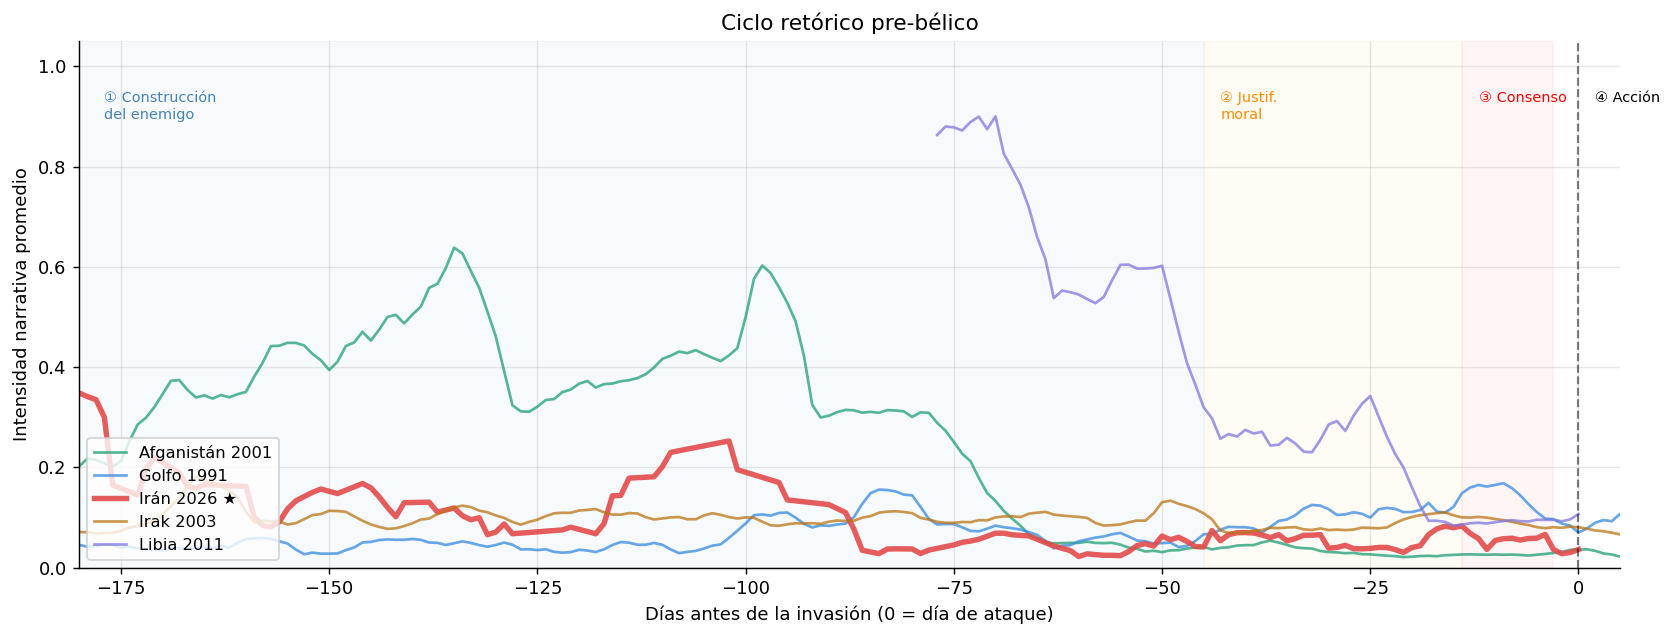

Guardado: ../img/fig1_ciclo_retorico.png


In [5]:
# Agrupar por caso y días antes de la invasión
weekly = (
    df
    .groupby(['case', 'days_before_invasion'])
    .agg(intensity=('narrative_intensity', 'mean'),
            articles=('NumArticles', 'sum'),
            tone=('AvgTone', 'mean'))
    .reset_index()
)

# Filtrar ventana de análisis y suavizar
weekly = weekly[weekly['days_before_invasion'] <= WINDOW_DAYS].copy()
weekly = weekly.sort_values(['case','days_before_invasion'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(13, 5))

for case, grp in weekly.groupby('case'):
    x = grp['days_before_invasion'].values[::-1] * -1  # negativo = antes
    y = grp['intensity'].rolling(ROLLING_WINDOW, center=True, min_periods=1).mean().values
    lw = 3 if case == 'iran_2026' else 1.5
    ax.plot(x, y, color=CASE_COLORS[case], label=CASE_LABELS[case],
            linewidth=lw, alpha=0.9 if case == 'iran_2026' else 0.75)

# Zonas de fase
ax.axvspan(-WINDOW_DAYS, -45, alpha=0.04, color='steelblue', label='_Fase ①')
ax.axvspan(-45, -14, alpha=0.04, color='orange', label='_Fase ②')
ax.axvspan(-14, -3, alpha=0.04, color='red', label='_Fase ③')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)

ax.text(-WINDOW_DAYS+3, 0.95, '① Construcción\ndel enemigo', fontsize=8, color='steelblue', va='top')
ax.text(-43, 0.95, '② Justif.\nmoral', fontsize=8, color='darkorange', va='top')
ax.text(-12, 0.95, '③ Consenso', fontsize=8, color='red', va='top')
ax.text(2, 0.95, '④ Acción', fontsize=8, va='top')

ax.set_xlabel('Días antes de la invasión (0 = día de ataque)', fontsize=10)
ax.set_ylabel('Intensidad narrativa promedio', fontsize=10)
ax.set_title('Ciclo retórico pre-bélico', fontsize=12)
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(-WINDOW_DAYS, 5)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../img/fig1_ciclo_retorico.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ../img/fig1_ciclo_retorico.png')

---
## 4. Hipótesis 2 — Aceleración del ciclo a través del tiempo

Para cada caso, medimos cuántos días tardó la intensidad en pasar de baja (< 0.2) a alta (> 0.6).  
Si la hipótesis es correcta, este número debería *decrecer* de 1991 a 2026.

,label,invasion_year,days_low_to_high
1,Golfo 1991,1991,167
0,Afganistán 2001,2001,25
2,Irak 2003,2003,44
3,Libia 2011,2011,28


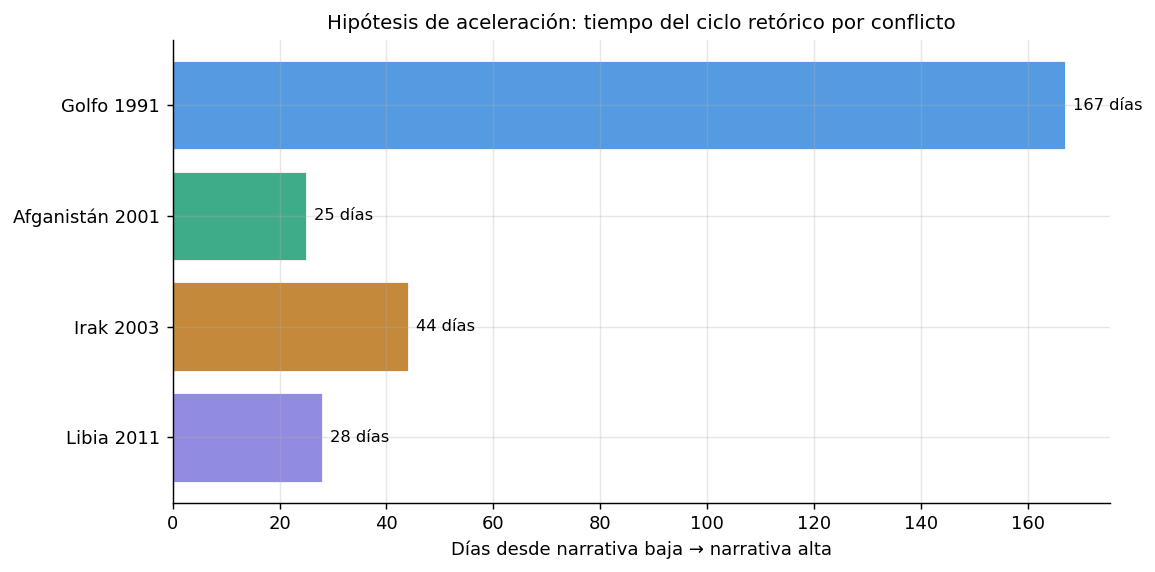

In [6]:
def measure_acceleration(df, threshold_low=0.20, threshold_high=0.60):
    """Mide cuántos días tarda cada caso en pasar de narrativa baja a alta."""
    results = []
    for case, grp in df.groupby('case'):
        grp = grp.sort_values('date')
        daily = grp.groupby('date')['narrative_intensity'].mean().reset_index()
        daily['smooth'] = daily['narrative_intensity'].rolling(7, min_periods=1).mean()

        # Primer día sobre threshold_low
        low_cross = daily[daily['smooth'] > threshold_low]['date'].min()
        # Primer día sobre threshold_high
        high_cross = daily[daily['smooth'] > threshold_high]['date'].min()

        if pd.notna(low_cross) and pd.notna(high_cross):
            duration = (high_cross - low_cross).days
            invasion = pd.Timestamp(INVASION_DATES[case])
            results.append({
                'case': case,
                'label': CASE_LABELS[case],
                'invasion_year': invasion.year,
                'days_low_to_high': duration,
                'color': CASE_COLORS[case],
            })
    return pd.DataFrame(results).sort_values('invasion_year')

accel = measure_acceleration(df)
display(accel[['label','invasion_year','days_low_to_high']])

# Visualización
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(accel['label'], accel['days_low_to_high'],
                color=accel['color'], alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, accel['days_low_to_high']):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val} días', va='center', fontsize=9)

ax.set_xlabel('Días desde narrativa baja → narrativa alta', fontsize=10)
ax.set_title('Hipótesis de aceleración: tiempo del ciclo retórico por conflicto', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../img/fig2_aceleracion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Tono mediático (AvgTone) — ¿cuándo se vuelve hostil la cobertura?

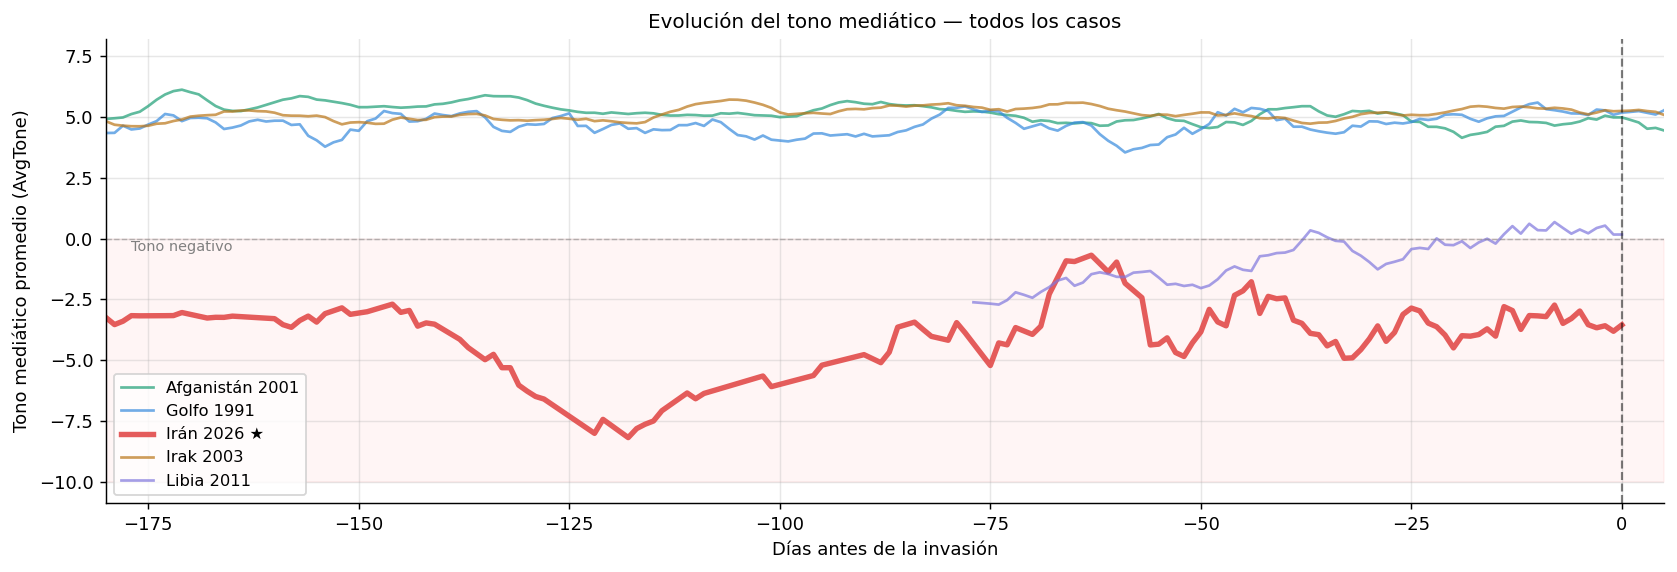

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))

for case, grp in weekly.groupby('case'):
    x = grp['days_before_invasion'].values[::-1] * -1
    y = grp['tone'].rolling(ROLLING_WINDOW, center=True, min_periods=1).mean().values
    lw = 3 if case == 'iran_2026' else 1.5
    ax.plot(x, y, color=CASE_COLORS[case], label=CASE_LABELS[case],
            linewidth=lw, alpha=0.9 if case == 'iran_2026' else 0.7)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.fill_between([-WINDOW_DAYS, 5], [-10, -10], [0, 0], alpha=0.04, color='red')
ax.text(-WINDOW_DAYS+3, -0.5, 'Tono negativo', fontsize=8, color='gray')

ax.set_xlabel('Días antes de la invasión', fontsize=10)
ax.set_ylabel('Tono mediático promedio (AvgTone)', fontsize=10)
ax.set_title('Evolución del tono mediático — todos los casos', fontsize=11)
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(-WINDOW_DAYS, 5)
plt.tight_layout()
plt.savefig('../img/fig3_tono_mediatico.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Distribución de fases — composición retórica por caso

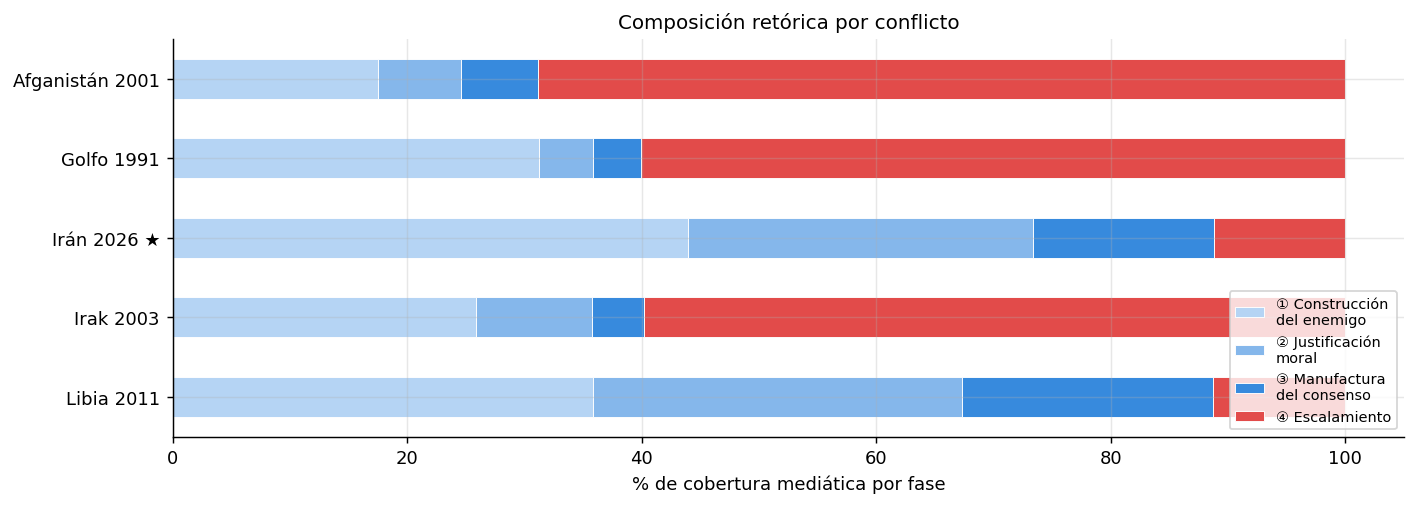

In [8]:
phase_order = ['construccion_enemigo', 'justificacion_moral', 'manufactura_consenso', 'escalamiento']
phase_labels = ['① Construcción\ndel enemigo', '② Justificación\nmoral',
                '③ Manufactura\ndel consenso', '④ Escalamiento']
phase_colors = ['#B5D4F4', '#85B7EB', '#378ADD', '#E24B4A']

pivot = (
    df.groupby(['case','phase'])['NumArticles']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=phase_order, fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.index = [CASE_LABELS[c] for c in pivot_pct.index]
pivot_pct.columns = phase_labels

fig, ax = plt.subplots(figsize=(11, 4))
pivot_pct.plot(kind='barh', stacked=True, ax=ax,
                color=phase_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('% de cobertura mediática por fase', fontsize=10)
ax.set_title('Composición retórica por conflicto', fontsize=11)
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../img/fig4_composicion_fases.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Caso Irán 2026 — zoom en tiempo real

Este caso es único: podemos seguir añadiendo datos mientras el conflicto ocurre.

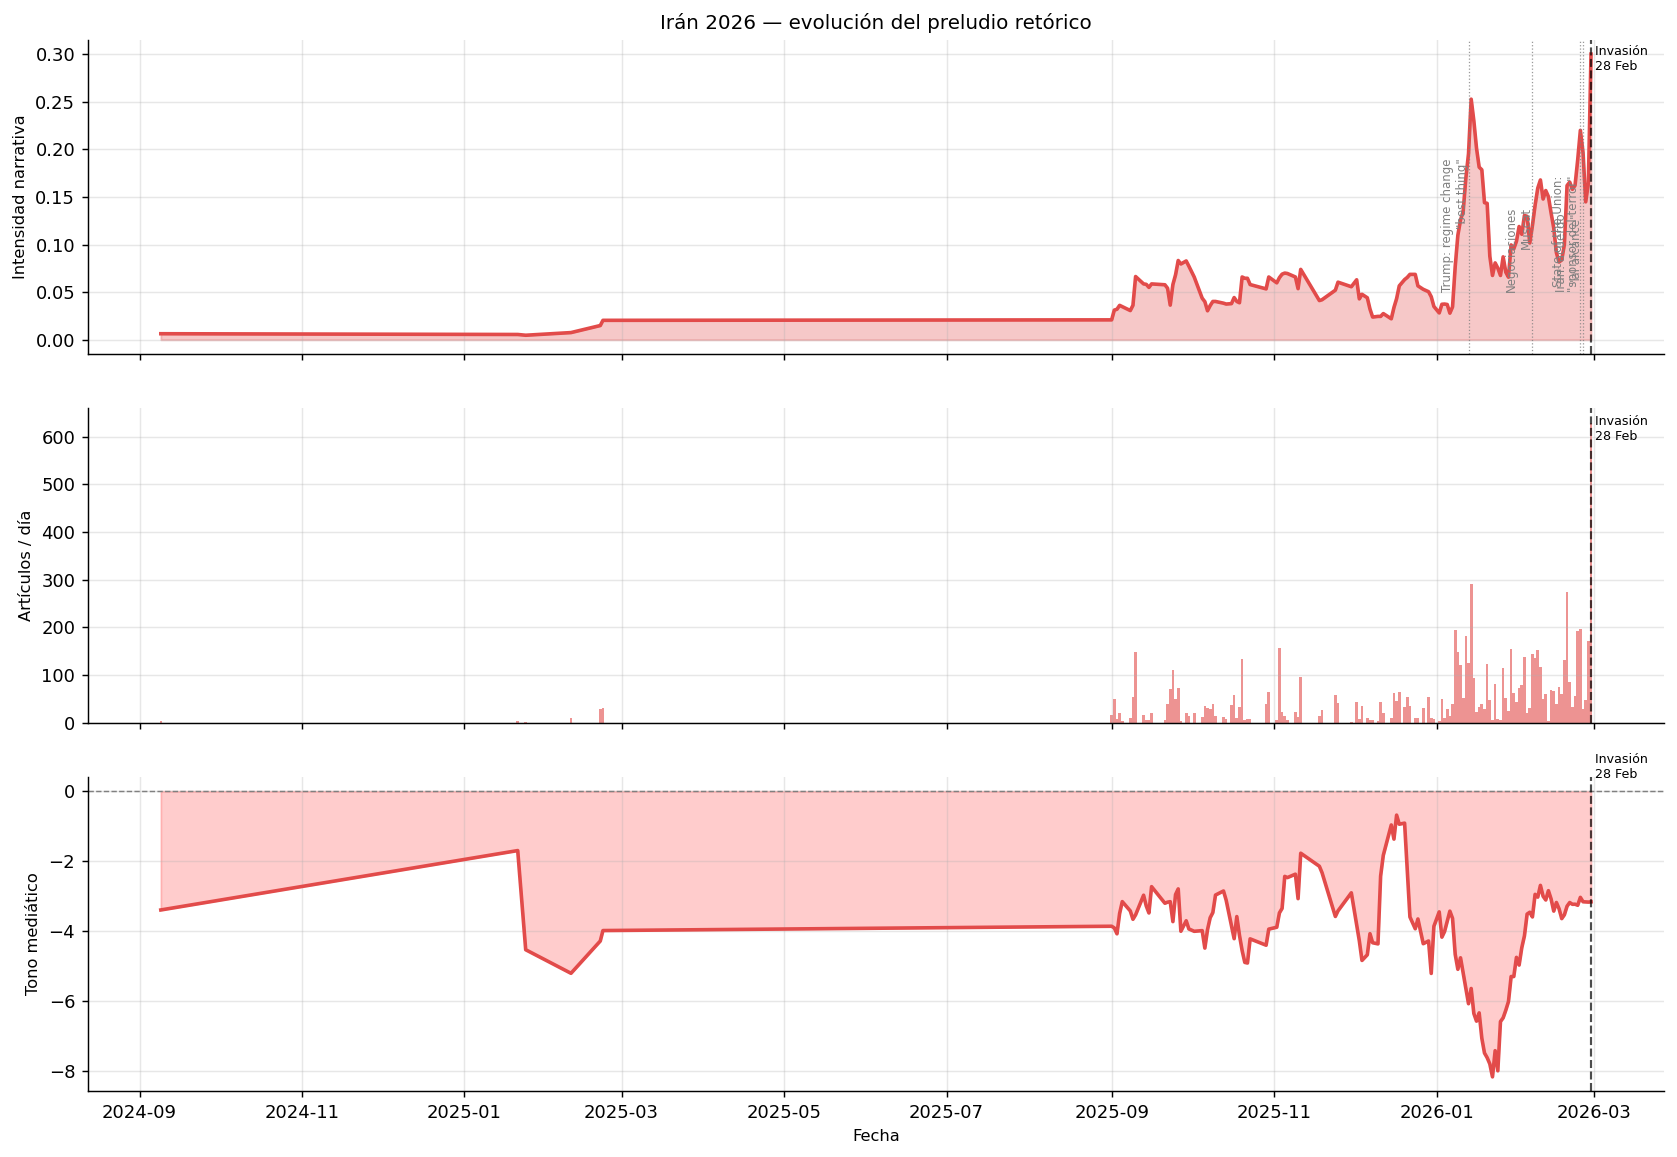

In [9]:
iran = df[df['case'] == 'iran_2026'].copy()
iran_daily = iran.groupby('date').agg(
    intensity=('narrative_intensity', 'mean'),
    articles=('NumArticles', 'sum'),
    tone=('AvgTone', 'mean'),
    hostile_events=('EventCode', lambda x: (x.isin(['190','193','194','195','138'])).sum())
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Panel 1: Intensidad
axes[0].fill_between(iran_daily['date'],
                        iran_daily['intensity'].rolling(7, min_periods=1).mean(),
                        alpha=0.3, color=CASE_COLORS['iran_2026'])
axes[0].plot(iran_daily['date'],
                iran_daily['intensity'].rolling(7, min_periods=1).mean(),
                color=CASE_COLORS['iran_2026'], linewidth=2)
axes[0].set_ylabel('Intensidad narrativa', fontsize=9)
axes[0].set_title('Irán 2026 — evolución del preludio retórico', fontsize=11)

# Panel 2: Volumen de artículos
axes[1].bar(iran_daily['date'], iran_daily['articles'],
            color=CASE_COLORS['iran_2026'], alpha=0.6, width=1)
axes[1].set_ylabel('Artículos / día', fontsize=9)

# Panel 3: Tono
axes[2].plot(iran_daily['date'],
                iran_daily['tone'].rolling(7, min_periods=1).mean(),
                color='#E24B4A', linewidth=2)
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[2].fill_between(iran_daily['date'],
                        iran_daily['tone'].rolling(7, min_periods=1).mean(),
                        0, alpha=0.2, color='red')
axes[2].set_ylabel('Tono mediático', fontsize=9)
axes[2].set_xlabel('Fecha', fontsize=9)

# Marca de invasión
invasion_dt = pd.Timestamp('2026-02-28')
for ax in axes:
    ax.axvline(invasion_dt, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(invasion_dt, ax.get_ylim()[1]*0.9, ' Invasión\n 28 Feb', fontsize=7)

# Hitos narrativos reales
hitos = [
    ('2026-01-13', 'Trump: regime change\n"best thing"'),
    ('2026-02-06', 'Negociaciones\nMuscat'),
    ('2026-02-24', 'State of the Union:\n"sponsor del terror"'),
    ('2026-02-25', 'Irán: acuerdo\n"al alcance"'),
]
for date_str, label in hitos:
    dt = pd.Timestamp(date_str)
    axes[0].axvline(dt, color='gray', linewidth=0.7, linestyle=':', alpha=0.8)
    axes[0].text(dt, 0.05, label, fontsize=6.5, color='gray',
                    rotation=90, va='bottom', ha='right')

plt.tight_layout()
plt.savefig('../img/fig5_iran_2026_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Variante 2 — Ciclos de redirección

La hipótesis de aceleración lineal no captura toda la historia.
Los datos muestran que **Afganistán 2001 es un outlier estructural**, no solo temporal.

### Dos primeras variantes del ciclo

| Tipo | Mecanismo | Duración típica | Ejemplos |
|------|-----------|-----------------|----------|
| **① Construcción** | El enemigo se fabrica desde narrativa baja; la amenaza es verificable o parcialmente real | Semanas–meses | Golfo 1991, Libia 2011 |
| **② Redirección** | Un evento detonante activa la emoción; el origen real se suprime y se apunta a otro objetivo | Días | Afganistán 2001 |

### El caso Afganistán — la hipótesis de la supresión saudí

15 de 19 secuestradores del 9/11 eran ciudadanos saudíes. Bin Laden era saudí.
Sin embargo, la invasión fue a Afganistán. Para que eso ocurriera, el ciclo necesitaba **dos operaciones simultáneas**:

1. **Operación A — redirigir el target:** mover foco `SAU → AFG/Taliban` via el marco *'harboring terrorists'*
2. **Operación B — suprimir el origen:** hacer caer sistemáticamente las menciones a Arabia Saudita

> Evidencia histórica: las 28 páginas del informe de la Comisión 9/11 estuvieron **clasificadas 15 años** (desclasificadas en 2016), documentando vínculos entre el gobierno saudí y los secuestradores.

**Redirection Index (RI):**
```
RI(t) = target_mentions(t) / (target_mentions(t) + suppressed_mentions(t))
```
Cuando RI converge a 1.0, la supresión está completa.

Datos v2: 2136 filas · columnas nuevas: cycle_type, target_mention_score, suppressed_mention_score


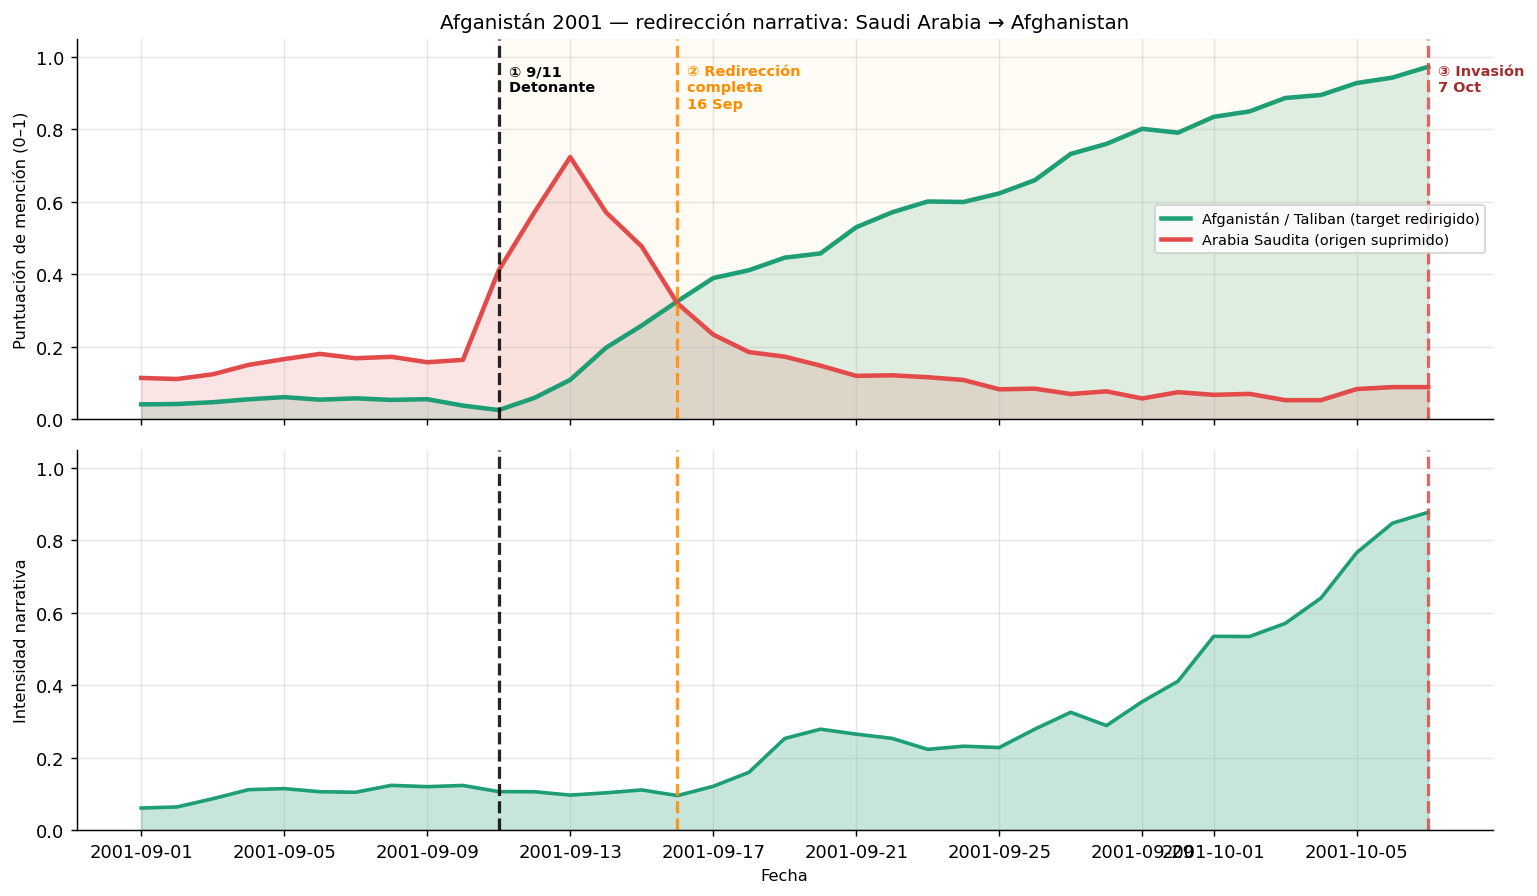

In [10]:
# Recarga datos v2 (con columnas target_mention_score y suppressed_mention_score)
df2 = pd.read_parquet('../data/gdelt_mock_v3.parquet')
df2['date'] = pd.to_datetime(df2['date'])
print(f'Datos v2: {len(df2)} filas · columnas nuevas: cycle_type, target_mention_score, suppressed_mention_score')

afg = df2[df2['case'] == 'afghanistan_2001'].copy()
afg_daily = afg.groupby('date').agg(
    intensity=('narrative_intensity', 'mean'),
    target=('target_mention_score', 'mean'),
    suppressed=('suppressed_mention_score', 'mean'),
).reset_index().sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Panel superior: cruce de menciones Saudi vs Afganistán
ax = axes[0]
t_smooth = afg_daily['target'].rolling(3, min_periods=1).mean()
s_smooth = afg_daily['suppressed'].rolling(3, min_periods=1).mean()

ax.fill_between(afg_daily['date'], t_smooth, alpha=0.15, color='#1D9E75')
ax.fill_between(afg_daily['date'], s_smooth, alpha=0.15, color='#E24B4A')
ax.plot(afg_daily['date'], t_smooth, color='#1D9E75', linewidth=2.5,
        label='Afganistán / Taliban (target redirigido)')
ax.plot(afg_daily['date'], s_smooth, color='#E24B4A', linewidth=2.5,
        label='Arabia Saudita (origen suprimido)')

det = pd.Timestamp('2001-09-11')
inv = pd.Timestamp('2001-10-07')

# Detectar cruce automáticamente (cuando Afghan supera a Saudi)
diff = t_smooth.values - s_smooth.values
cross_idx = next((i for i in range(1, len(diff)) if diff[i-1] <= 0 and diff[i] > 0), None)
cross_date = afg_daily['date'].iloc[cross_idx] if cross_idx else pd.Timestamp('2001-09-18')

# ── Hito 1: 9/11 ──────────────────────────────────────────────────────────
ax.axvline(det, color='black', linewidth=1.8, linestyle='--', alpha=0.85)
ax.text(det, 0.98, '  ① 9/11\n  Detonante', fontsize=8, va='top', fontweight='bold')

# ── Hito 2: cruce narrativo ────────────────────────────────────────────────
ax.axvline(cross_date, color='darkorange', linewidth=1.8, linestyle='--', alpha=0.85)
ax.text(cross_date, 0.98, f'  ② Redirección\n  completa\n  {cross_date.strftime("%d %b")}',
        fontsize=8, va='top', color='darkorange', fontweight='bold')

# ── Hito 3: invasión ──────────────────────────────────────────────────────
ax.axvline(inv, color='#E24B4A', linewidth=1.8, linestyle='--', alpha=0.85)
ax.text(inv, 0.98, '  ③ Invasión\n  7 Oct', fontsize=8, va='top',
        color='#A32D2D', fontweight='bold')

# Zona de redirección activa
ax.axvspan(det, inv, alpha=0.04, color='orange')

ax.set_ylabel('Puntuación de mención (0–1)', fontsize=9)
ax.set_title('Afganistán 2001 — redirección narrativa: Saudi Arabia → Afghanistan', fontsize=11)
ax.legend(loc='center right', fontsize=8)
ax.set_ylim(0, 1.05)

# Panel inferior: intensidad general
ax2 = axes[1]
int_smooth = afg_daily['intensity'].rolling(3, min_periods=1).mean()
ax2.fill_between(afg_daily['date'], int_smooth, alpha=0.25, color='#1D9E75')
ax2.plot(afg_daily['date'], int_smooth, color='#1D9E75', linewidth=2)
ax2.axvline(det, color='black', linewidth=1.8, linestyle='--', alpha=0.85)
ax2.axvline(cross_date, color='darkorange', linewidth=1.8, linestyle='--', alpha=0.85)
ax2.axvline(inv, color='#E24B4A', linewidth=1.8, linestyle='--', alpha=0.85)
ax2.set_ylabel('Intensidad narrativa', fontsize=9)
ax2.set_xlabel('Fecha', fontsize=9)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../img/fig6_redireccion_afganistan.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparación cross-case: construcción vs. redirección

En los ciclos de **construcción**, el target sube gradualmente en paralelo con la intensidad narrativa.  
En el ciclo de **redirección** (Afganistán), vemos el patrón de tijera: el origen cae mientras el target sube — dentro de una ventana de apenas 26 días.

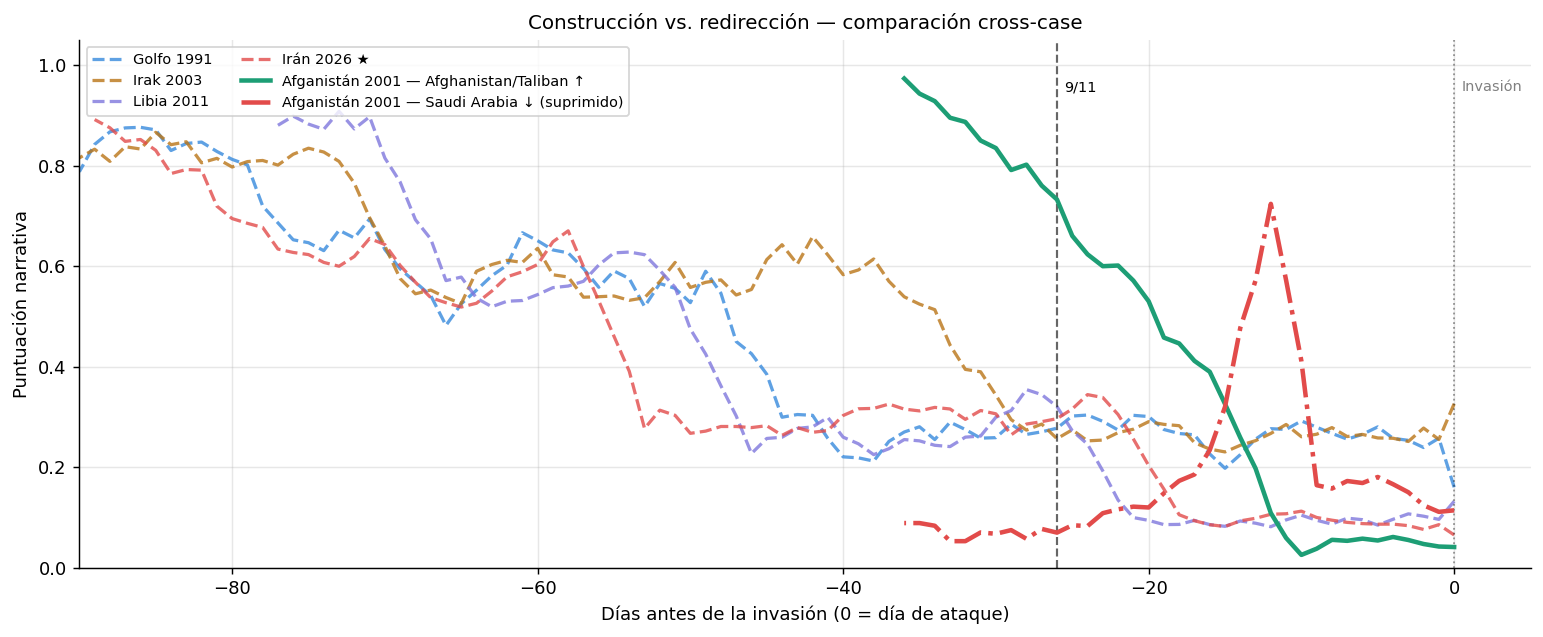

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

# Ciclos de construcción — intensidad narrativa del target
for case in ['gulf_1991', 'iraq_2003', 'libya_2011', 'iran_2026']:
    sub = df2[df2['case'] == case].copy()
    inv_date = sub['date'].max()
    daily = sub.groupby('date')['narrative_intensity'].mean().reset_index().sort_values('date')
    daily['days_before'] = [(inv_date - d).days for d in daily['date']]
    daily = daily[daily['days_before'] <= 90]
    x = daily['days_before'].values[::-1] * -1
    y = daily['narrative_intensity'].rolling(5, min_periods=1).mean().values
    ax.plot(x, y, color=CASE_COLORS[case], label=CASE_LABELS[case],
            linewidth=1.8, alpha=0.8, linestyle='--')

# Afganistán: AMBAS curvas (target sube, Saudi cae)
inv_afg = pd.Timestamp('2001-10-07')
det_afg = pd.Timestamp('2001-09-11')
afg2_d = df2[df2['case'] == 'afghanistan_2001'].groupby('date').agg(
    target=('target_mention_score', 'mean'),
    suppressed=('suppressed_mention_score', 'mean'),
).reset_index().sort_values('date')
afg2_d['days_before'] = [(inv_afg - d).days for d in afg2_d['date']]
afg2_d = afg2_d[afg2_d['days_before'] <= 90]
x_a = afg2_d['days_before'].values[::-1] * -1

ax.plot(x_a, afg2_d['target'].rolling(3, min_periods=1).mean().values,
        color='#1D9E75', linewidth=2.5, label='Afganistán 2001 — Afghanistan/Taliban ↑', zorder=5)
ax.plot(x_a, afg2_d['suppressed'].rolling(3, min_periods=1).mean().values,
        color='#E24B4A', linewidth=2.5, linestyle='-.', label='Afganistán 2001 — Saudi Arabia ↓ (suprimido)', zorder=5)

det_days = -((inv_afg - det_afg).days)
ax.axvline(det_days, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(det_days + 0.5, 0.97, '9/11', fontsize=8, va='top')
ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.4)
ax.text(0.5, 0.97, 'Invasión', fontsize=8, va='top', color='gray')

ax.set_xlabel('Días antes de la invasión (0 = día de ataque)', fontsize=10)
ax.set_ylabel('Puntuación narrativa', fontsize=10)
ax.set_title('Construcción vs. redirección — comparación cross-case', fontsize=11)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_xlim(-90, 5)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../img/fig7_construccion_vs_redireccion.png', dpi=150, bbox_inches='tight')
plt.show()

### Cómo validar esto con datos reales de GDELT

La columna `Actor1CountryCode` / `Actor2CountryCode` de GDELT permite medir exactamente este patrón.
Para el caso Afganistán 2001, buscar en GDELT:

```python
# Filtrar eventos donde USA interactúa con SAU o AFG en el período Sep–Oct 2001
query_saudi = 'Saudi Arabia terrorism 9/11'
query_afghan = 'Afghanistan Taliban Al-Qaeda'
# Comparar volumen semanal de cada query → el cruce de curvas es el índice de redirección
```

**Métrica propuesta — Redirection Index (RI):**

```
RI(t) = target_mentions(t) / (target_mentions(t) + suppressed_mentions(t))
```

- `RI ≈ 0.5` el día del evento (ambos en el discurso)
- `RI → 1.0` cuando la supresión es completa (solo el target en el discurso)
- La velocidad de convergencia a 1.0 mide qué tan eficiente fue la operación de redirección


---
## 10. Variante 3 — Fabricación de evidencia

La tercera variante cierra la taxonomía y es quizás la más sofisticada.
No construye el enemigo desde cero ni redirige uno existente — **inventa o exagera una capacidad**
que justifica una acción urgente, sabiendo que esa capacidad probablemente no existe.

### La paradoja de la disuasión nuclear

> *Si un país realmente tuviera armas de destrucción masiva, atacarlo sería suicida.*  
> *Por eso EE.UU. nunca invadió la URSS, China ni Corea del Norte después de que desarrollaron la bomba.*

Esto revela una paradoja estructural en los casos de Irak 2003 e Irán 2026:
**la amenaza nuclear no puede ser real si el ataque se ejecuta** — lo que convierte
la narrativa de WMDs/bomba nuclear no en una razón para atacar, sino en
la justificación narrativa que hace posible hacerlo.

### Evidencia empírica disponible

| Caso | Claim narrativa | Evidencia real | Fuente de refutación |
|------|----------------|----------------|----------------------|
| **Irak 2003** | WMDs verificadas por inteligencia | Nunca encontradas | Informe Chilcot (2016), inspectores ONU |
| **Irán 2026** | Misiles que alcanzarán EE.UU. | DIA: capacidad hasta 2035 | Reporte DIA filtrado, feb. 2026 |

### Taxonomía completa

| # | Tipo | Mecanismo | EGI esperado | Ejemplos |
|---|------|-----------|--------------|----------|
| ① | **Construcción verificable** | Amenaza real; narrativa se construye gradualmente | Bajo — evidencia sigue a las claims | Golfo 1991, Libia 2011 |
| ② | **Redirección** | Evento detonante; origen real suprimido | Medio — evidencia parcial del evento | Afganistán 2001 |
| ③ | **Fabricación de evidencia** | Claims sistemáticamente por encima de la evidencia verificable | **Alto y sostenido** — gap nunca se cierra | Irak 2003, Irán 2026 |

### Evidence Gap Index (EGI)

```
EGI(t) = claim_intensity(t) − evidence_score(t)

EGI ≈ 0.0  → narrativa respaldada por hechos verificables
EGI > 0.35 sostenido → señal de posible fabricación
```

Con datos reales de GDELT + Miller Center, `claim_intensity` se mide con volumen
de artículos y tono, y `evidence_score` se construye cruzando con reportes de
agencias de inteligencia, inspecciones internacionales (IAEA, ONU) y documentos desclasificados.

In [12]:
# Recarga datos v3 (agrega evidence_score, evidence_gap, evidence_profile)
df3 = pd.read_parquet('../data/gdelt_mock_v3.parquet')
df3['date'] = pd.to_datetime(df3['date'])
print(f'Datos v3: {len(df3)} filas')
print(f'Columnas nuevas: evidence_score, evidence_gap, evidence_profile, cycle_type')
print()
print(df3.groupby(['case','cycle_type','evidence_profile'])[['evidence_gap']].mean().round(3))

Datos v3: 2136 filas
Columnas nuevas: evidence_score, evidence_gap, evidence_profile, cycle_type

                                                evidence_gap
case             cycle_type   evidence_profile              
afghanistan_2001 redirection  partial                  0.201
gulf_1991        construction verified                 0.067
iran_2026        fabrication  fabricated               0.342
iraq_2003        fabrication  fabricated               0.302
libya_2011       construction verified                 0.075


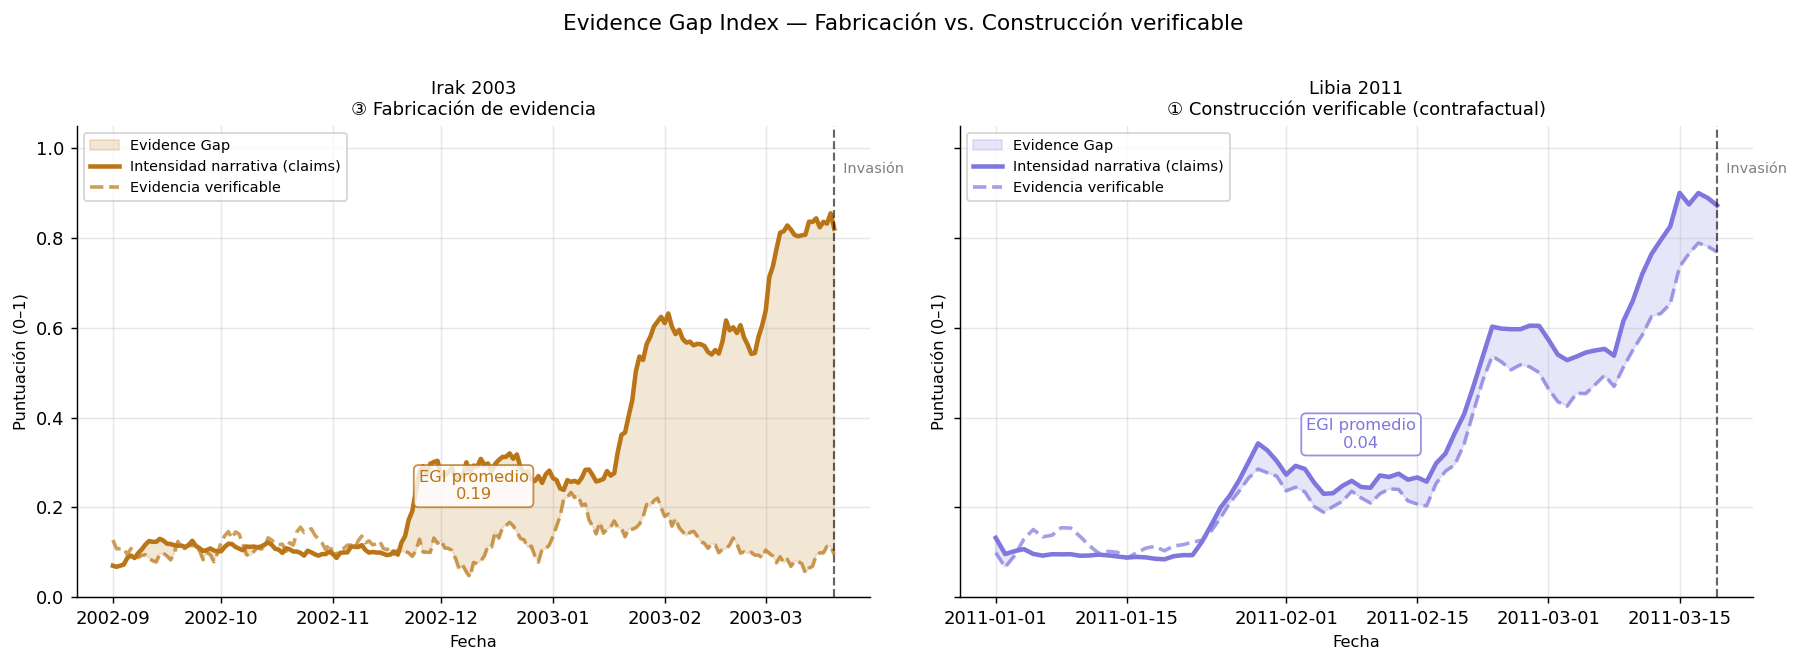

In [13]:
CASE_COLORS_LOCAL = {
    'gulf_1991':'#378ADD','afghanistan_2001':'#1D9E75',
    'iraq_2003':'#BA7517','libya_2011':'#7F77DD','iran_2026':'#E24B4A',
}
CASE_LABELS_LOCAL = {
    'gulf_1991':'Golfo 1991','afghanistan_2001':'Afganistán 2001',
    'iraq_2003':'Irak 2003','libya_2011':'Libia 2011','iran_2026':'Irán 2026 ★',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, case, subtitle in zip(axes,
    ['iraq_2003', 'libya_2011'],
    ['③ Fabricación de evidencia', '① Construcción verificable (contrafactual)']):

    sub = df3[df3['case']==case].copy()
    inv = sub['date'].max()
    daily = sub.groupby('date').agg(
        claims=('narrative_intensity','mean'),
        evidence=('evidence_score','mean'),
        gap=('evidence_gap','mean'),
    ).reset_index().sort_values('date')

    c_sm = daily['claims'].rolling(7, min_periods=1).mean()
    e_sm = daily['evidence'].rolling(7, min_periods=1).mean()

    ax.fill_between(daily['date'], c_sm, e_sm,
                    where=(c_sm >= e_sm), alpha=0.18,
                    color=CASE_COLORS_LOCAL[case], label='Evidence Gap')
    ax.plot(daily['date'], c_sm, color=CASE_COLORS_LOCAL[case],
            linewidth=2.5, label='Intensidad narrativa (claims)')
    ax.plot(daily['date'], e_sm, color=CASE_COLORS_LOCAL[case],
            linewidth=2, linestyle='--', alpha=0.7, label='Evidencia verificable')

    ax.axvline(inv, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.text(inv, 0.97, '  Invasión', fontsize=8, va='top', color='gray')

    gap_mean = (c_sm - e_sm).mean()
    mid = daily['date'].iloc[len(daily)//2]
    ax.annotate(f'EGI promedio\n{gap_mean:.2f}',
                xy=(mid, (c_sm.mean()+e_sm.mean())/2),
                fontsize=9, ha='center', color=CASE_COLORS_LOCAL[case],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=CASE_COLORS_LOCAL[case], alpha=0.8))

    ax.set_title(f'{CASE_LABELS_LOCAL[case]}\n{subtitle}', fontsize=10)
    ax.set_ylabel('Puntuación (0–1)', fontsize=9)
    ax.set_xlabel('Fecha', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Evidence Gap Index — Fabricación vs. Construcción verificable', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../img/fig8_evidence_gap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### EGI cross-case — todos los conflictos en el mismo eje

Los ciclos de **fabricación** (línea sólida) muestran un gap alto y sostenido durante todo el preludio.
Los ciclos de **construcción** (línea discontinua) tienen un gap bajo — claims y evidencia van juntas.
La **redirección** (Afganistán) tiene un perfil intermedio: el evento del 9/11 es verificable,
pero la conexión AFG no lo es completamente.

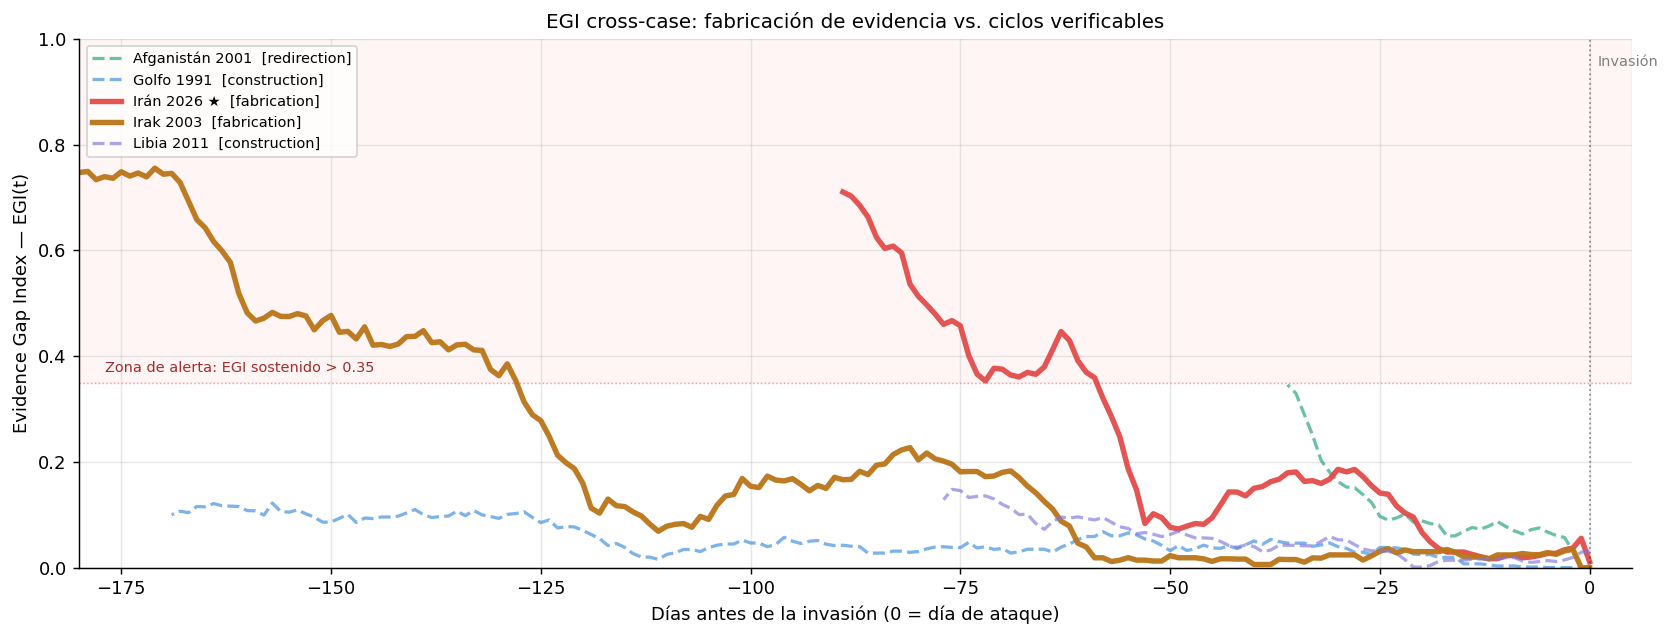

In [14]:
WINDOW = 180
fig, ax = plt.subplots(figsize=(13, 5))

for case, grp in df3.groupby('case'):
    inv_date = grp['date'].max()
    daily = grp.groupby('date')['evidence_gap'].mean().reset_index()
    daily['days_before'] = [(inv_date - d).days for d in daily['date']]
    daily = daily[daily['days_before'] <= WINDOW].sort_values('days_before', ascending=False)
    x = daily['days_before'].values[::-1] * -1
    y = daily['evidence_gap'].rolling(10, min_periods=1).mean().values

    cycle = grp['cycle_type'].iloc[0]
    lw    = 3   if cycle == 'fabrication' else 1.8
    ls    = '-' if cycle == 'fabrication' else '--'
    alpha = 0.95 if cycle == 'fabrication' else 0.65
    ax.plot(x, y, color=CASE_COLORS_LOCAL[case],
            label=f"{CASE_LABELS_LOCAL[case]}  [{cycle}]",
            linewidth=lw, linestyle=ls, alpha=alpha)

ax.axhspan(0.35, 1.0, alpha=0.04, color='red')
ax.axhline(0.35, color='#E24B4A', linewidth=0.8, linestyle=':', alpha=0.5)
ax.text(-WINDOW+3, 0.37, 'Zona de alerta: EGI sostenido > 0.35', fontsize=8, color='#A32D2D')
ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.4)
ax.text(1, 0.97, 'Invasión', fontsize=8, va='top', color='gray')

ax.set_xlabel('Días antes de la invasión (0 = día de ataque)', fontsize=10)
ax.set_ylabel('Evidence Gap Index — EGI(t)', fontsize=10)
ax.set_title('EGI cross-case: fabricación de evidencia vs. ciclos verificables', fontsize=11)
ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(-WINDOW, 5)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('../img/fig9_egi_crosscase.png', dpi=150, bbox_inches='tight')
plt.show()


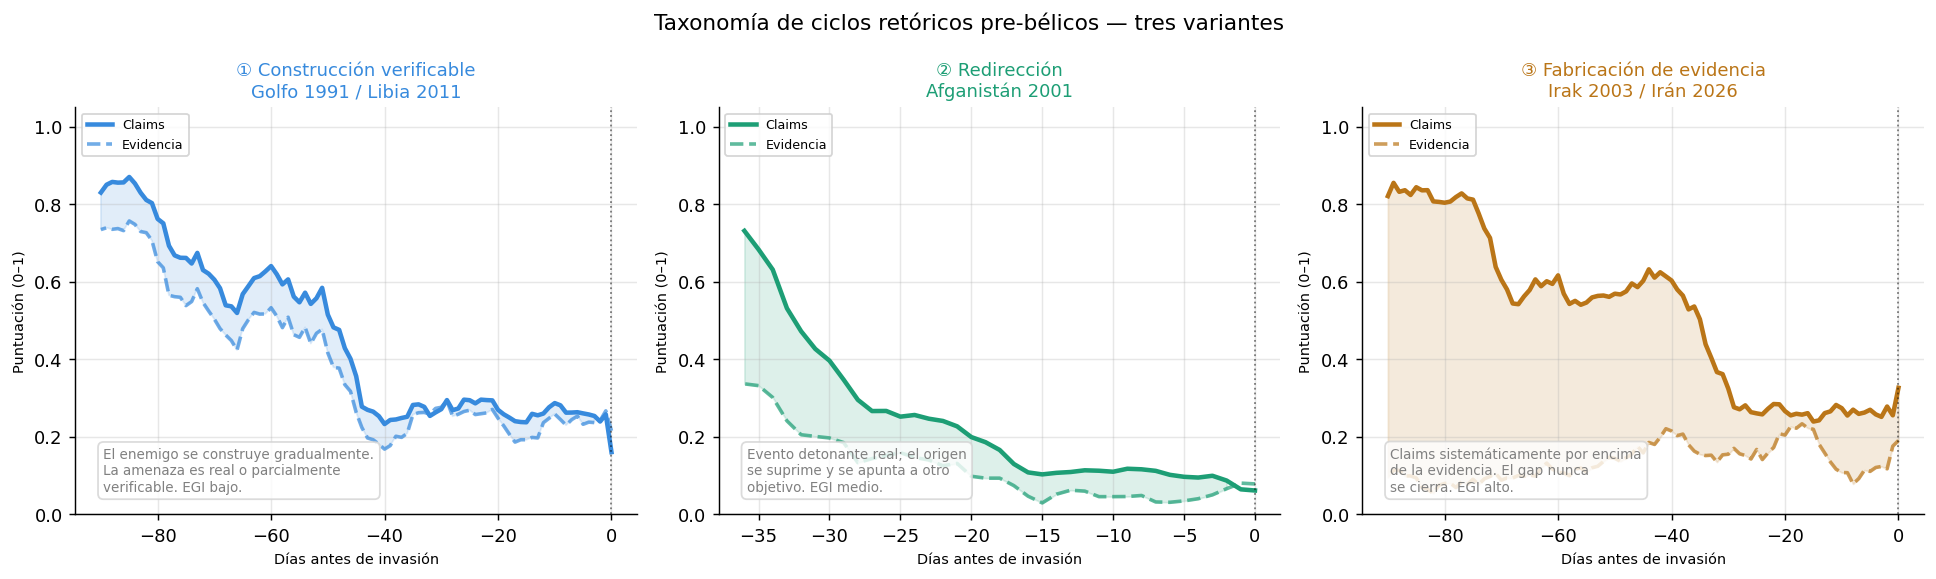

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

profiles = [
    ('gulf_1991',        '① Construcción verificable', 'Golfo 1991 / Libia 2011',
     'El enemigo se construye gradualmente.\nLa amenaza es real o parcialmente\nverificable. EGI bajo.'),
    ('afghanistan_2001', '② Redirección',              'Afganistán 2001',
     'Evento detonante real; el origen\nse suprime y se apunta a otro\nobjetivo. EGI medio.'),
    ('iraq_2003',        '③ Fabricación de evidencia', 'Irak 2003 / Irán 2026',
     'Claims sistemáticamente por encima\nde la evidencia. El gap nunca\nse cierra. EGI alto.'),
]

for ax, (case, tipo, ejemplos, desc) in zip(axes, profiles):
    sub = df3[df3['case']==case].copy()
    inv_date = sub['date'].max()
    daily = sub.groupby('date').agg(
        claims=('narrative_intensity','mean'),
        evidence=('evidence_score','mean'),
    ).reset_index()
    daily['days_before'] = [(inv_date - d).days for d in daily['date']]
    daily = daily[daily['days_before'] <= 90].sort_values('days_before', ascending=False)
    x = daily['days_before'].values[::-1] * -1
    c = daily['claims'].rolling(7, min_periods=1).mean().values
    e = daily['evidence'].rolling(7, min_periods=1).mean().values

    ax.fill_between(x, c, e, where=(c>=e), alpha=0.15, color=CASE_COLORS_LOCAL[case])
    ax.plot(x, c, color=CASE_COLORS_LOCAL[case], linewidth=2.5, label='Claims')
    ax.plot(x, e, color=CASE_COLORS_LOCAL[case], linewidth=2,
            linestyle='--', alpha=0.7, label='Evidencia')
    ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.5)

    ax.set_title(f'{tipo}\n{ejemplos}', fontsize=10, color=CASE_COLORS_LOCAL[case])
    ax.set_xlabel('Días antes de invasión', fontsize=8)
    ax.set_ylabel('Puntuación (0–1)', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.text(0.05, 0.05, desc, transform=ax.transAxes, fontsize=7.5, va='bottom', color='gray',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='lightgray'))

fig.suptitle('Taxonomía de ciclos retóricos pre-bélicos — tres variantes', fontsize=12)
plt.tight_layout()
plt.savefig('../img/fig10_taxonomia.png', dpi=150, bbox_inches='tight')
plt.show()


### Cómo construir EGI con datos reales

```python
# claim_intensity → GDELT: volumen de artículos + AvgTone negativo por semana
# evidence_score  → cruzar con:
#   - Reportes IAEA: https://www.iaea.org/resources/reports
#   - Resoluciones ONU: https://research.un.org/en/docs/sc/quick
#   - Miller Center (discursos): https://millercenter.org/the-presidency/presidential-speeches
#   - Documentos desclasificados: https://www.archives.gov/research/declassification

# Proxy simple para empezar:
# evidence_score(t) = 1 si hay un evento verificable externo esa semana, 0 si no
# (inspección IAEA, resolución ONU, incidente militar confirmado)
```

**Señal de alerta temprana propuesta:**
> Si `EGI(t) > 0.35` durante más de 30 días consecutivos antes de una invasión,
> clasificar el ciclo como **fabricación de evidencia** con alta probabilidad.


---
## 11. Próximos pasos

### Para activar datos reales
1. Pon `USE_REAL_GDELT = True` en la celda de configuración
2. Instala dependencias: `pip install gdelt requests pyarrow`
3. Comenzar por **Irak 2003** — caso más documentado, ideal para validar la taxonomía

### Análisis pendientes por sección
- **§9 Redirección**: medir RI(t) real con menciones SAU vs AFG en GDELT Sep–Oct 2001
- **§10 Fabricación**: construir evidence_score real cruzando GDELT con reportes IAEA + ONU
- **§10 EGI real**: validar umbral 0.35 con datos históricos de Irak 2003
- **NLP / Topic modeling**: BERTopic sobre titulares — detectar marcos retóricos por fase
- **Framing analysis con LLM**: clasificar noticias en tipo de ciclo usando Claude API
- **Test estadístico**: regresión `duración_ciclo ~ año` solo para ciclos de construcción
- **Detección automática**: clasificar un nuevo conflicto en las tres variantes en tiempo real
- **Pipeline en tiempo real**: ingesta diaria de GDELT para seguir Irán 2026

### Fuentes para evidence_score real
- **IAEA**: informes de inspección nuclear → `https://www.iaea.org/resources/reports`
- **Resoluciones ONU**: `https://research.un.org/en/docs/sc/quick`
- **Miller Center**: discursos presidenciales transcritos → `https://millercenter.org`
- **Informe Chilcot** (Irak 2003): `https://www.iraqinquiry.org.uk`
- **28 páginas 9/11** (desclasificadas 2016): `https://www.dni.gov/files/documents/icotr/51117/2016_Declassified_28_Pgs.pdf`
- **Reporte DIA Irán** (feb. 2026): rastrear via FOIA o fuentes periodísticas verificadas
- **ACLED**: eventos de conflicto geolocalizados → `https://acleddata.com/`
